# House Price Prediction Notebook

This notebook walks through:
1. **Imports**  
2. **Data Loading & Cleaning**  
3. **Exploratory Data Analysis (EDA)**  
4. **Preprocessing Functions**  
5. **Preprocessing Execution**  
6. **Feature Engineering**  
7. **Feature Engineering Execution**  
8. **Feature Matrix Construction**  
9. **Model Benchmarking**  
10. **Hyperparameter Tuning**  
11. **Final Training & Submission**  

## 1. Import Libraries

In [2]:

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Model Selection
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_validate

# Metrics
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error

# Models
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

# Utilities
from collections import Counter

# 2. Load Dataset

In [3]:
def load_and_clean_raw():
    """Load raw CSVs and drop unneeded columns."""
    df      = pd.read_csv('data/development.csv')
    df_eval = pd.read_csv('data/evaluation.csv')
    orig_eval_ids = df_eval['id'].copy()

    # Columns to remove from training and evaluation
    drop_cols = [
        'id','time','source','longitude','latitude','address',
        'price_type','currency','body','title'
    ]
    df      = df.drop(columns=drop_cols)
    # In eval, keep 'id' so drop all except id
    eval_drop = [c for c in drop_cols if c != 'id' and c in df_eval]
    df_eval = df_eval.drop(columns=eval_drop)

    return df, df_eval, orig_eval_ids

# Load
df, df_eval, orig_eval_ids = load_and_clean_raw()


# 3. Exploratory Data Analysis (EDA)


3.1. Quick Overview


In [4]:
# Shape and dtypes
print("Training data shape:", df.shape)
print(df.dtypes.value_counts(), "\n")

Training data shape: (79589, 11)
str        7
float64    3
int64      1
Name: count, dtype: int64 



In [5]:
# Preview
display(df.head())

,category,amenities,bathrooms,bedrooms,fee,has_photo,pets_allowed,price,square_feet,cityname,state
0,housing/rent/apartment,"Clubhouse,Playground",1.0,2.0,No,Yes,"Cats,Dogs",760.0,930,Taylors,SC
1,housing/rent/apartment,"Garbage Disposal,Parking,Storage,Washer Dryer,...",1.0,2.0,No,Yes,NaN,1699.0,750,Los Angeles,CA
2,housing/rent/apartment,"Clubhouse,Fireplace,Parking,Patio/Deck,Storage...",1.0,1.0,No,Yes,"Cats,Dogs",775.0,652,Euless,TX
3,housing/rent/apartment,NaN,2.0,2.0,No,Yes,NaN,1395.0,841,Elkridge,MD
4,housing/rent/apartment,Washer Dryer,1.0,2.0,No,No,Cats,865.0,900,Bismarck,ND


# 3.2. Missing Values

In [6]:
missing = df.isna().mean().sort_values(ascending=False) * 100
print("Missing (%) per column:")
print(missing[missing > 0])

Missing (%) per column:
pets_allowed    60.711907
amenities       16.087650
cityname         0.294010
state            0.294010
bedrooms         0.111824
bathrooms        0.064079
dtype: float64


# 3.3 Price Distribution

We deliberately cut off the top 1% of prices when plotting—i.e. we only show values up to the 99th percentile (≈$4 000)—so the histogram focuses on the bulk of the data. The overall max (≈$52 000) still exists in the raw summary, but those extreme outliers were omitted from the x-axis to prevent the long tail from squashing the main distribution.

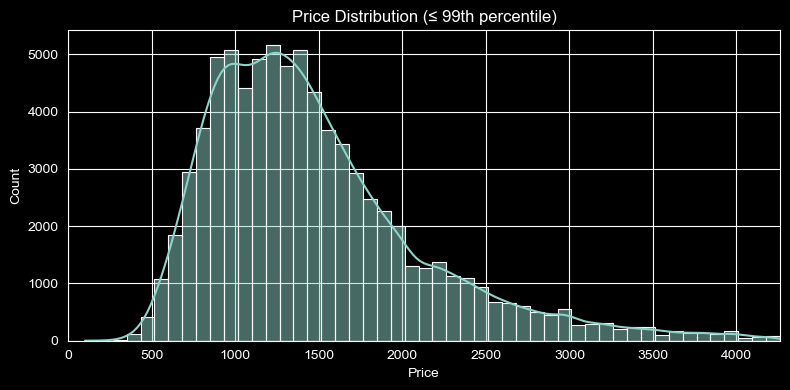

The count of prices equal to 1000 is: 358


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Determine cutoff at the 99th percentile to shorten the tail
cutoff = df['price'].quantile(0.99)

plt.figure(figsize=(8, 4))

# Plot only prices up to the 99th percentile
sns.histplot(df.loc[df['price'] <= cutoff, 'price'],
             bins=50,
             kde=True)

# Mirror the original styling
plt.title('Price Distribution (≤ 99th percentile)')
plt.xlabel('Price')
plt.ylabel('Count')

# Optional: explicitly set x-limits to the same cutoff
plt.xlim(0, cutoff)

plt.tight_layout()
plt.show()

# Count the number of occurrences of price equal to 1000
count_1000 = df[df['price'] == 1000].shape[0]

# Print the result
print(f"The count of prices equal to 1000 is: {count_1000}")

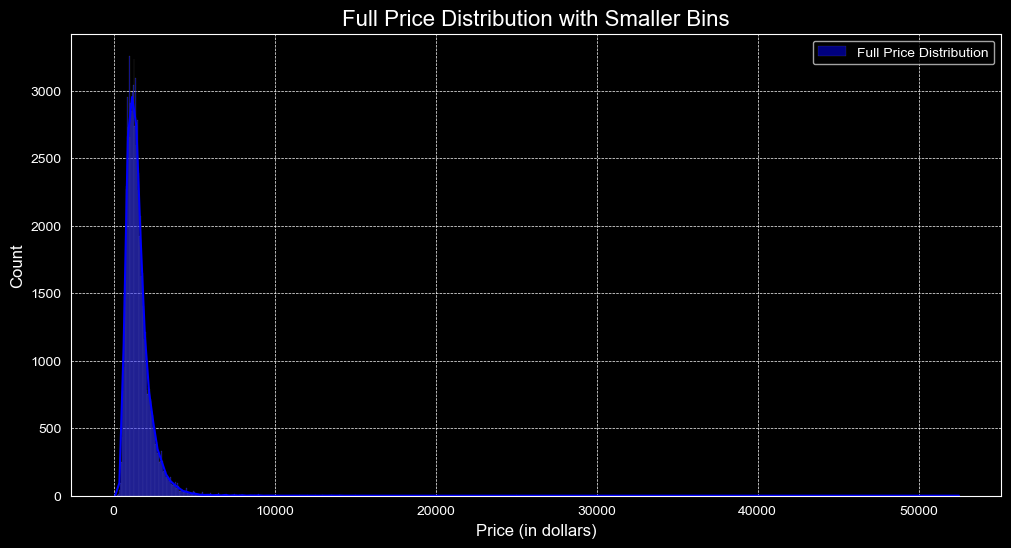

The count of prices equal to 1000 is: 358


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a smaller bin width for better granularity (to ensure even sparse data is captured)
bin_width = 50  # Adjust this based on your data distribution

# Create a better-structured plot with clearer bins and labels
plt.figure(figsize=(12, 6))

# Plot the full price distribution (blue) with a smaller bin width
sns.histplot(df['price'], color='blue', label='Full Price Distribution', bins=range(0, int(df['price'].max()) + bin_width, bin_width), kde=True)

# Add a clear title, axis labels, and grid for better readability
plt.title('Full Price Distribution with Smaller Bins', fontsize=16)
plt.xlabel('Price (in dollars)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Show the legend to explain the colors
plt.legend()

# Display grid lines for clarity
plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

plt.show()

# Count the number of occurrences of price equal to 1000
count_1000 = df[df['price'] == 1000].shape[0]

# Print the result
print(f"The count of prices equal to 1000 is: {count_1000}")

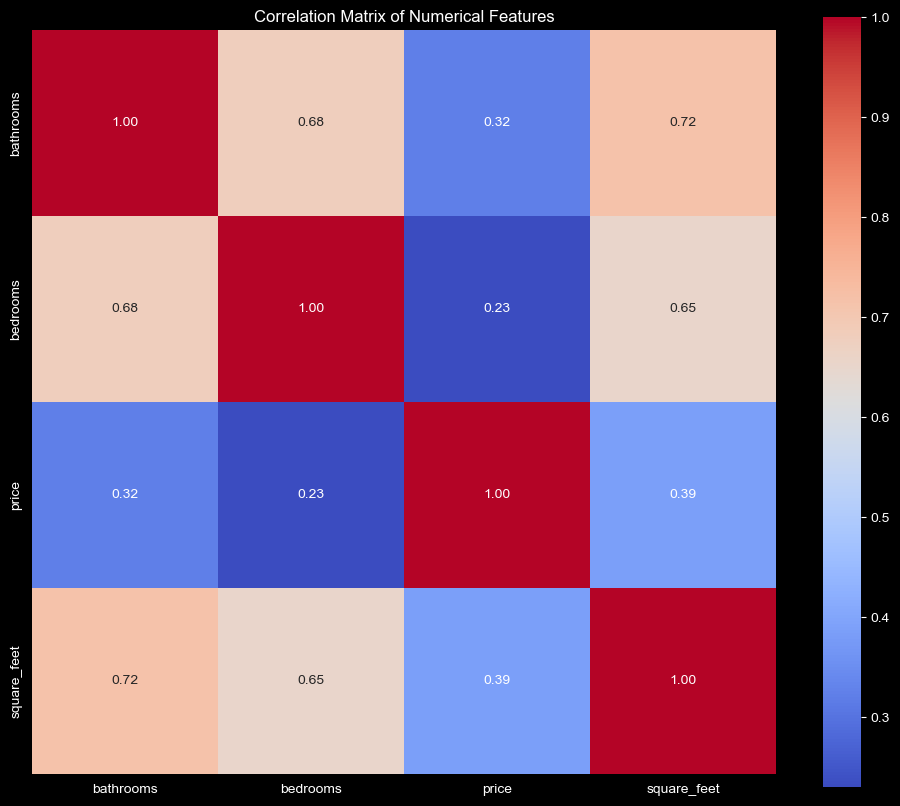

In [9]:
# Select numeric columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
corr = df[num_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# 4. Data Cleaning & Imputation

In [10]:
def clean_missing(df, df_eval):
    """Handle missing city/state and numeric fields."""
    # Drop rows missing key location info in training
    df = df.dropna(subset=['cityname','state']).reset_index(drop=True)
    # Fill with 'Unknown' in eval
    df_eval['cityname'] = df_eval['cityname'].fillna('Unknown')
    df_eval['state']    = df_eval['state'].fillna('Unknown')

    # Numeric medians
    for col in ['bathrooms','bedrooms']:
        med = df[col].median()
        df[col]      = df[col].fillna(med)
        df_eval[col] = df_eval[col].fillna(med)

    return df, df_eval

df, df_eval = clean_missing(df, df_eval)

# 5. Encoding & Feature Engineering

5.1. Smoothed Target Encoding for Categorical

In [11]:
def smooth_target_encoding(df, df_eval, m_state=50, m_city=100):
    global_mean = df['price'].mean()

    def _encode(src, tgt, col, m):
        stats = src.groupby(col)['price'].agg(['mean','count'])
        stats['enc'] = (stats['mean']*stats['count'] + global_mean*m) / (stats['count'] + m)
        tgt[col+'_enc'] = tgt[col].map(stats['enc']).fillna(global_mean)
        src[col+'_enc'] = src[col].map(stats['enc'])
        src.drop(columns=[col], inplace=True)
        tgt.drop(columns=[col], inplace=True)

    _encode(df, df_eval, 'state',    m_state)
    _encode(df, df_eval, 'cityname', m_city)

smooth_target_encoding(df, df_eval)


5.2. Binary Flags for Pets, Photos & Fees


In [12]:
def make_binary_flags(df, df_eval):
    def encode_pets(x):
        if pd.isna(x): return np.nan
        return 0 if str(x).strip().lower()=='none' else 1

    def encode_photo(x):
        if pd.isna(x): return 0
        return 1 if str(x).strip().lower() in ('yes','thumbnail') else 0

    for frame in (df, df_eval):
        # Pets allowed
        pets = frame['pets_allowed'].apply(encode_pets)
        frame['pets_allowed_bin'] = pets.fillna(pets.median())
        frame.drop(columns=['pets_allowed'], inplace=True)

        # Has photo
        photos = frame['has_photo'].apply(encode_photo)
        frame['has_photo_bin'] = photos
        frame.drop(columns=['has_photo'], inplace=True)

        # Fee
        fees = frame['fee'].astype(str).str.lower().map({'yes':1,'no':0})
        frame['has_fee'] = fees.fillna(0).astype(int)
        frame.drop(columns=['fee'], inplace=True)

make_binary_flags(df, df_eval)


5.3. Filter to Housing Rentals & Apartment Flag

In [13]:
def filter_flag_category(df, df_eval):
    keep = ['housing/rent/apartment','housing/rent/home']
    df_h = df[df['category'].isin(keep)].reset_index(drop=True)
    df_e = df_eval[df_eval['category'].isin(keep)].reset_index(drop=True)

    for frame in (df_h, df_e):
        frame['is_apartment'] = (frame['category']=='housing/rent/apartment').astype(int)
        frame.drop(columns=['category'], inplace=True)

    return df_h, df_e

df_high, df_eval_high = filter_flag_category(df, df_eval)

5.4. Amenities & Square-Feet Features

In [14]:
def process_amenities_sqft(df, df_eval):
    # Split amenities
    for frame in (df, df_eval):
        frame['amenities'] = frame['amenities'].fillna('')
        frame['amenities_list'] = [
            [a.strip() for a in s.split(',') if a.strip()]
            for s in frame['amenities']
        ]
        frame['amenity_count'] = frame['amenities_list'].apply(len)

    # Top 10 amenities → one-hot
    top10 = [
        a for a,_ in Counter(a for L in df['amenities_list'] for a in L)
        .most_common(10)
    ]
    for amen in top10:
        col = f"has_{amen.lower().replace(' ','_')}"
        df[col]        = df['amenities_list'].apply(lambda L: int(amen in L))
        df_eval[col]   = df_eval['amenities_list'].apply(lambda L: int(amen in L))

    # Drop raw amenities
    for frame in (df, df_eval):
        frame.drop(columns=['amenities','amenities_list'], inplace=True)

    # Winsorize square_feet and log + scale
    p1, p99 = df['square_feet'].quantile([0.01,0.99])
    for frame in (df, df_eval):
        frame['sqft_wins'] = frame['square_feet'].clip(p1, p99)
        frame['log_sqft']  = np.log1p(frame['sqft_wins'])

    scaler = StandardScaler()
    df['sqft_scaled']       = scaler.fit_transform(df[['log_sqft']])
    df_eval['sqft_scaled']  = scaler.transform(df_eval[['log_sqft']])

    for frame in (df, df_eval):
        frame.drop(columns=['square_feet','sqft_wins','log_sqft'], inplace=True)

    return df, df_eval

df_high, df_eval_high = process_amenities_sqft(df_high, df_eval_high)


5.5. Room-Related Features

In [15]:
def add_room_features(df, df_eval):
    def _feats(X):
        X = X.copy()
        X['room_count']     = X['bedrooms'] + X['bathrooms']
        X['bed_bath_ratio'] = (
            X['bedrooms'] /
            X['bathrooms'].replace(0, np.nan)
        ).fillna(0)
        return X

    return _feats(df), _feats(df_eval)

df_high, df_eval_high = add_room_features(df_high, df_eval_high)

# 6. Build Feature Matrix

In [20]:
def build_feature_matrix(df):
    """Return (X_array, feature_names)."""
    base_feats = [
        'sqft_scaled','bedrooms','bathrooms','room_count',
        'bed_bath_ratio','amenity_count','pets_allowed_bin',
        'has_photo_bin','has_fee','state_enc','cityname_enc',
        'is_apartment'
    ]
    amen_feats = [c for c in df.columns if c.startswith('has_')]
    features = base_feats + amen_feats
    X = df[features].values
    return X, features

X, feature_names = build_feature_matrix(df_high)
y = df_high['price'].values


# 7. Model Benchmarking

In [17]:
def benchmark_models(X, y):
    """Train several regressors via 5-fold CV and report R², RMSE, MAE."""
    models = {
        'Lasso': TransformedTargetRegressor(
            Lasso(alpha=0.1, max_iter=10000, random_state=42),
            func=np.log1p, inverse_func=np.expm1
        ),
        'Ridge': TransformedTargetRegressor(
            Ridge(alpha=10.0, random_state=42),
            func=np.log1p, inverse_func=np.expm1
        ),
        'KNN': TransformedTargetRegressor(
            KNeighborsRegressor(
                n_neighbors=10, weights='distance', n_jobs=-1
            ),
            func=np.log1p, inverse_func=np.expm1
        ),
        'RF': TransformedTargetRegressor(
            RandomForestRegressor(
                n_estimators=300, max_features=0.5,
                min_samples_leaf=1, random_state=42, n_jobs=-1
            ),
            func=np.log1p, inverse_func=np.expm1
        ),
        'XGBoost': TransformedTargetRegressor(
            XGBRegressor(
                n_estimators=300, learning_rate=0.1, max_depth=10,
                subsample=0.8, colsample_bytree=1.0,
                random_state=42, n_jobs=-1, verbosity=0
            ),
            func=np.log1p, inverse_func=np.expm1
        )
    }

    scoring = {
        'r2':   'r2',
        'rmse': make_scorer(mean_squared_error, squared=False),
        'mae':  make_scorer(mean_absolute_error)
    }

    results = {}
    for name, mdl in models.items():
        cv = cross_validate(mdl, X, y, cv=5, scoring=scoring)
        results[name] = {
            'R²':   np.mean(cv['test_r2']),
            'RMSE': np.mean(cv['test_rmse']),
            'MAE':  np.mean(cv['test_mae'])
        }
    return pd.DataFrame(results).T, models

metrics_df, model_dict = benchmark_models(X, y)

print("## Cross-Validation Results")
display(metrics_df)


## Cross-Validation Results


,R²,RMSE,MAE
Lasso,0.448553,NaN,347.068256
Ridge,0.550204,NaN,316.492172
KNN,0.670905,NaN,193.073501
RF,0.724131,NaN,186.974452
XGBoost,0.727241,NaN,189.965009


# 8. Benchmark Visualization: Heatmap

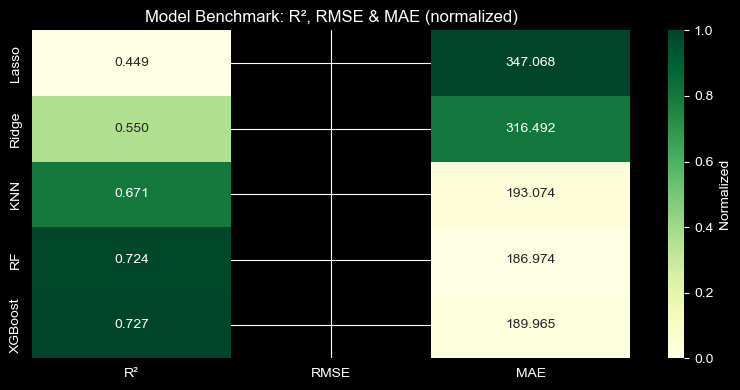

In [18]:
# Normalize each metric to [0,1] for color scaling
normed = (metrics_df - metrics_df.min()) / (metrics_df.max() - metrics_df.min())

plt.figure(figsize=(8, 4))
sns.heatmap(
    normed, annot=metrics_df, fmt=".3f",
    cmap='YlGn', cbar_kws={'label': 'Normalized'}
)
plt.title('Model Benchmark: R², RMSE & MAE (normalized)')
plt.tight_layout()
plt.show()

# 9. Train Final Model & Create Submission

In [19]:
def train_and_submit(best_model, df_train, df_eval, features, orig_ids):
    """Fit best_model on all training data, predict on eval, save CSV."""
    X_full = df_train[features].values
    y_full = df_train['price'].values
    best_model.fit(X_full, y_full)

    X_eval = df_eval[features].values
    preds  = best_model.predict(X_eval)

    # Build submission frame
    sub = pd.DataFrame({'id': df_eval['id'], 'price': preds})
    # Ensure order matches original eval IDs
    final = pd.DataFrame({'id': orig_ids}).merge(sub, on='id', how='left')
    global_mean = y_full.mean()
    final['price'] = final['price'].fillna(global_mean)
    final.rename(columns={'id':'Id','price':'Predicted'}, inplace=True)
    final.to_csv('submission.csv', index=False)
    print("→ submission.csv saved.", final.shape)

# Pick best
best = model_dict['RF']
train_and_submit(best, df_high, df_eval_high, feature_names, orig_eval_ids)


→ submission.csv saved. (19898, 2)
